<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-cancer-rates-by-country-ml-95?scriptVersionId=237194762" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cancer-rate-by-countries/Global cancer mortality in males and females (2022).csv
/kaggle/input/cancer-rate-by-countries/Cancer frequency.csv
/kaggle/input/cancer-rate-by-countries/Global cancer incidence in males and females (2022).csv
/kaggle/input/cancer-rate-by-countries/Overall global cancer incidence (2022).csv
/kaggle/input/cancer-rate-by-countries/Overall global cancer mortality (2022).csv


## Title:
Global Cancer Rates by Country

## Description:
A snapshot of cancer incidence across countries, highlighting variations in rates and potential influencing factors.

In [2]:
df = pd.read_csv('/kaggle/input/cancer-rate-by-countries/Overall global cancer mortality (2022).csv', encoding='ISO-8859-1')


In [3]:
df.head()

,Country,Including NMSC Number,Including NMSC Rate,Excluding NMSC Number,Excluding NMSC Rate
0,ÿMongolia,"4,929",181.5,"4,923",181.3
1,ÿZimbabwe,"11,739",144.0,"11,599",142.1
2,ÿHungary,"32,482",143.7,"32,245",142.9
3,ÿPoland,"119,992",133.1,"118,982",132.4
4,ÿRomania,"56,216",132.5,"55,627",131.5


In [4]:
df.tail()

,Country,Including NMSC Number,Including NMSC Rate,Excluding NMSC Number,Excluding NMSC Rate
181,ÿUnited Arab Emirates,"2,283",54.4,"2,264",53.9
182,ÿCongo,"1,732",52.9,"1,729",52.8
183,ÿSaudi Arabia,"13,399",46.2,"13,312",45.8
184,ÿQatar,782,46.2,781,46.1
185,ÿSierra Leone,"1,334",25.5,"1,334",25.5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                186 non-null    object 
 1   Including NMSC Number  186 non-null    object 
 2    Including NMSC Rate   186 non-null    float64
 3   Excluding NMSC Number  186 non-null    object 
 4   Excluding NMSC Rate    186 non-null    float64
dtypes: float64(2), object(3)
memory usage: 7.4+ KB


In [6]:
df.describe()

,Including NMSC Rate,Excluding NMSC Rate
count,186.000000,186.000000
mean,90.449462,89.742473
std,21.736665,21.606135
min,25.500000,25.500000
25%,75.475000,74.900000
50%,90.050000,89.500000
75%,103.950000,103.200000
max,181.500000,181.300000


In [7]:
df.isnull().sum()

Country                  0
Including NMSC Number    0
 Including NMSC Rate     0
Excluding NMSC Number    0
Excluding NMSC Rate      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Country                   object
Including NMSC Number     object
 Including NMSC Rate     float64
Excluding NMSC Number     object
Excluding NMSC Rate      float64
dtype: object

In [10]:
df.shape

(186, 5)

In [11]:
df.columns

Index(['Country', 'Including NMSC Number', ' Including NMSC Rate',
       'Excluding NMSC Number', 'Excluding NMSC Rate'],
      dtype='object')

## Data visualizations

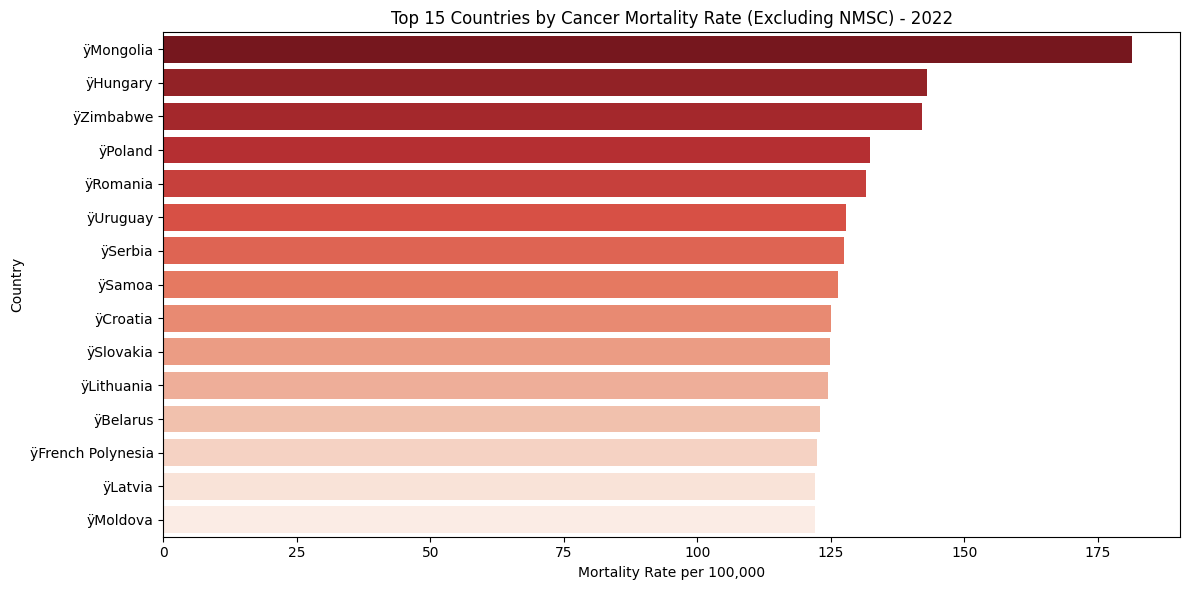

In [12]:
# Clean column names
df.columns = df.columns.str.strip()

# Sort by Excluding NMSC Rate and select top 15
top15_excl_rate = df.sort_values(by='Excluding NMSC Rate', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top15_excl_rate, x='Excluding NMSC Rate', y='Country', palette='Reds_r')
plt.title('Top 15 Countries by Cancer Mortality Rate (Excluding NMSC) - 2022')
plt.xlabel('Mortality Rate per 100,000')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [13]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert numeric columns that may have strings (like commas) to proper numbers
cols_to_convert = ['Including NMSC Number', 'Including NMSC Rate',
                   'Excluding NMSC Number', 'Excluding NMSC Rate']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# Drop rows with missing Country or numeric values
df.dropna(subset=['Country'] + cols_to_convert, inplace=True)


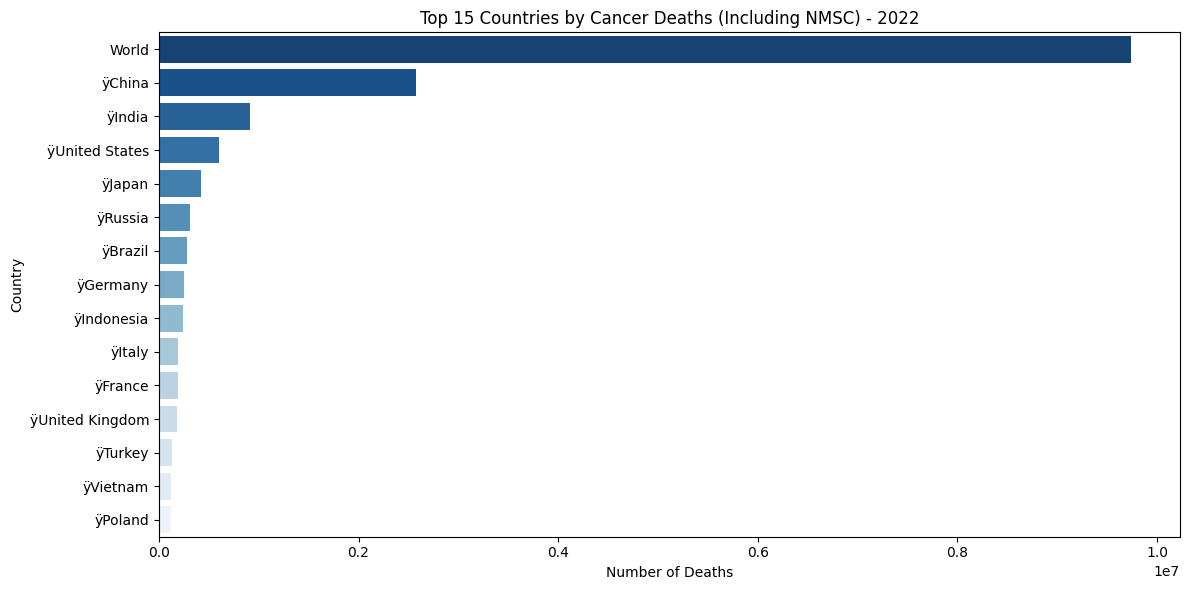

In [14]:
top15_incl_number = df.sort_values(by='Including NMSC Number', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top15_incl_number, x='Including NMSC Number', y='Country', palette='Blues_r')
plt.title('Top 15 Countries by Cancer Deaths (Including NMSC) - 2022')
plt.xlabel('Number of Deaths')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


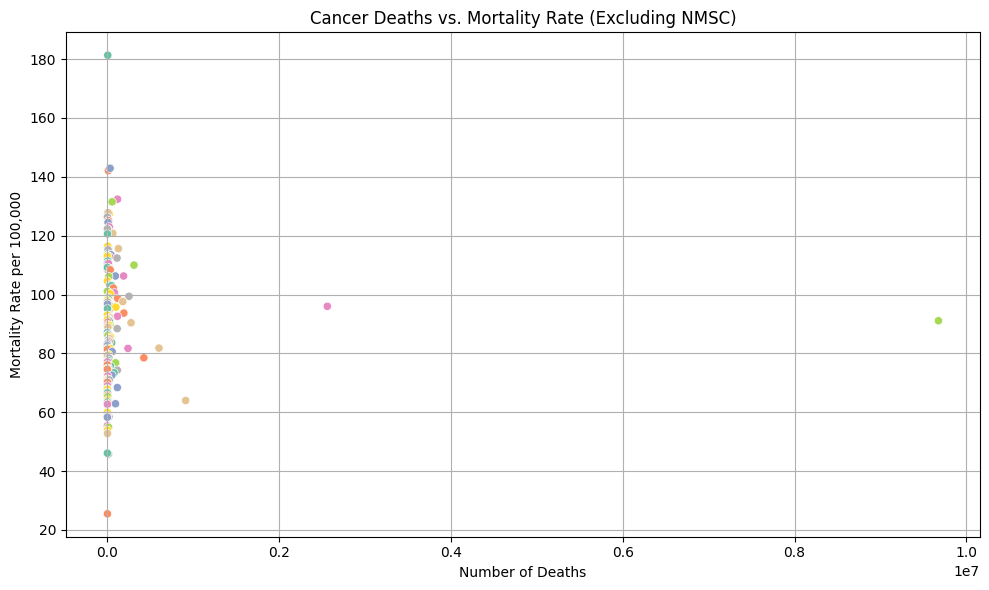

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Excluding NMSC Number', y='Excluding NMSC Rate', hue='Country', legend=False, palette='Set2')
plt.title('Cancer Deaths vs. Mortality Rate (Excluding NMSC)')
plt.xlabel('Number of Deaths')
plt.ylabel('Mortality Rate per 100,000')
plt.grid(True)
plt.tight_layout()
plt.show()


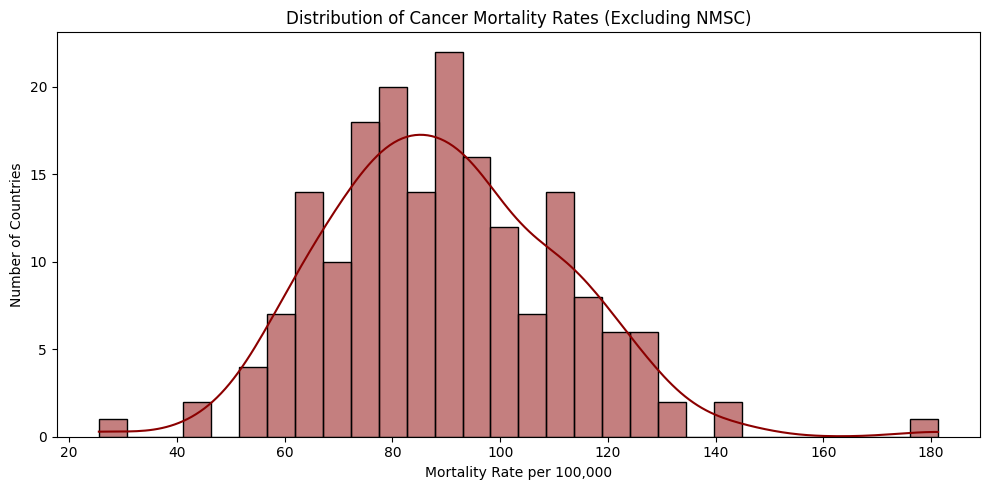

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Excluding NMSC Rate'], bins=30, kde=True, color='darkred')
plt.title('Distribution of Cancer Mortality Rates (Excluding NMSC)')
plt.xlabel('Mortality Rate per 100,000')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.show()


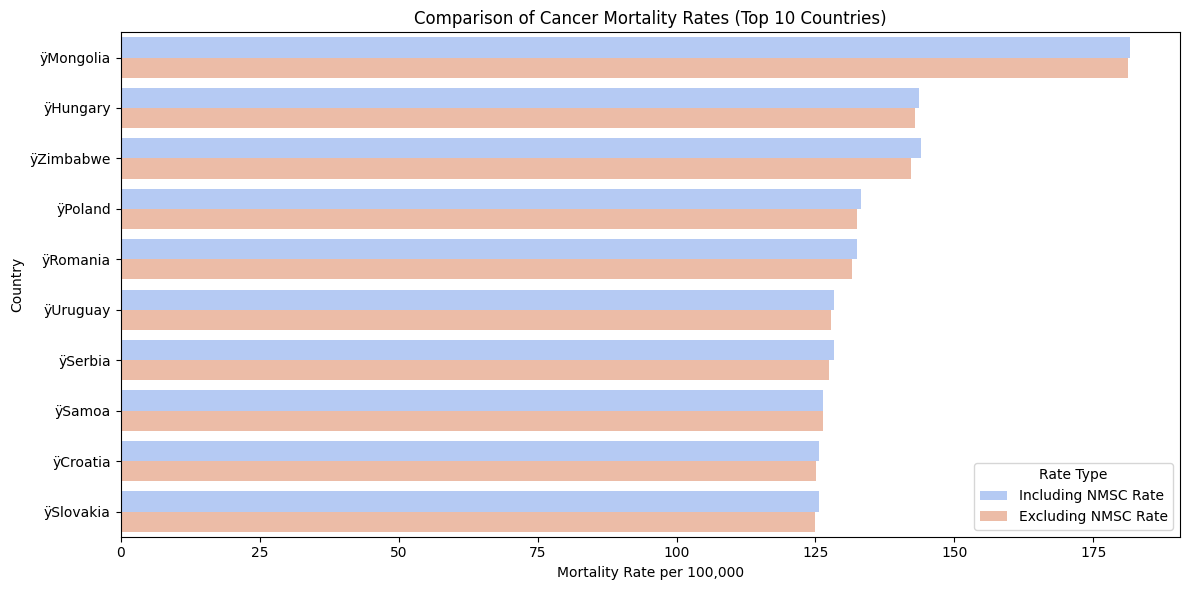

In [17]:
top10 = df.sort_values(by='Excluding NMSC Rate', ascending=False).head(10)

# Melt for side-by-side barplot
melted = top10.melt(id_vars='Country', value_vars=['Including NMSC Rate', 'Excluding NMSC Rate'],
                    var_name='Type', value_name='Rate')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x='Rate', y='Country', hue='Type', palette='coolwarm')
plt.title('Comparison of Cancer Mortality Rates (Top 10 Countries)')
plt.xlabel('Mortality Rate per 100,000')
plt.ylabel('Country')
plt.legend(title='Rate Type')
plt.tight_layout()
plt.show()


## Predictive modeling|

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert string numbers to numeric
cols_to_convert = ['Including NMSC Number', 'Including NMSC Rate',
                   'Excluding NMSC Number', 'Excluding NMSC Rate']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df.dropna(inplace=True)

# Create binary label: high cancer rate vs low cancer rate (based on median)
median_rate = df['Including NMSC Rate'].median()
df['High_Cancer_Rate'] = (df['Including NMSC Rate'] > median_rate).astype(int)

In [20]:
# Encode country
le = LabelEncoder()
df['Country_encoded'] = le.fit_transform(df['Country'])

# Features and target
X = df[['Country_encoded', 'Including NMSC Number', 'Excluding NMSC Number', 'Excluding NMSC Rate']]
y = df['High_Cancer_Rate']


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



📌 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.56      0.53      0.54        19
           1       0.55      0.58      0.56        19

    accuracy                           0.55        38
   macro avg       0.55      0.55      0.55        38
weighted avg       0.55      0.55      0.55        38



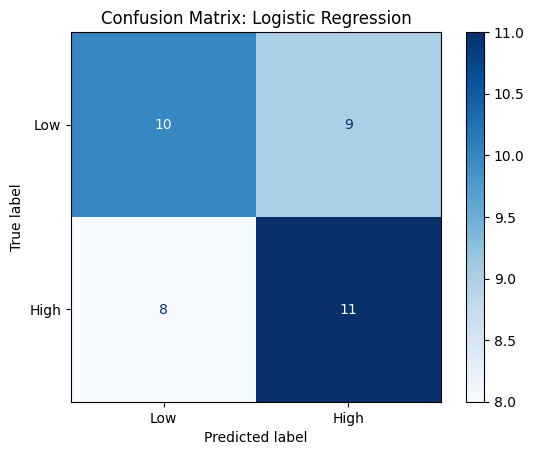


📌 Model: Decision Tree
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.84      0.91        19

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.93      0.92      0.92        38



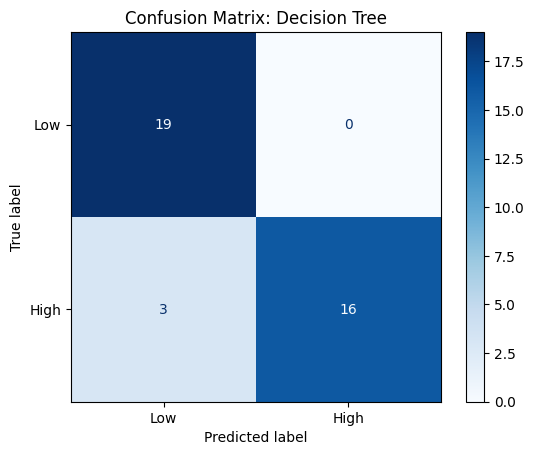


📌 Model: Random Forest
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.84      0.91        19

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.93      0.92      0.92        38



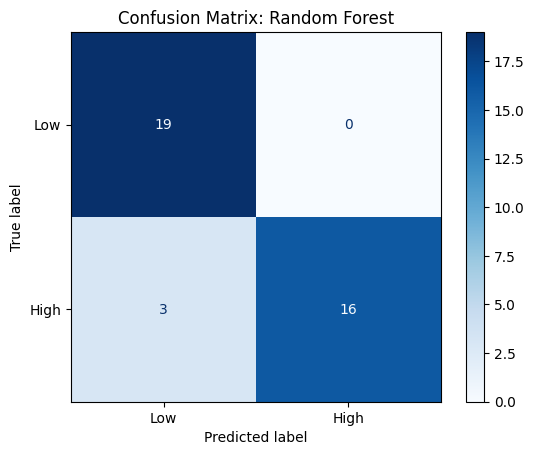


📌 Model: Support Vector Machine
              precision    recall  f1-score   support

           0       0.48      0.84      0.62        19
           1       0.40      0.11      0.17        19

    accuracy                           0.47        38
   macro avg       0.44      0.47      0.39        38
weighted avg       0.44      0.47      0.39        38



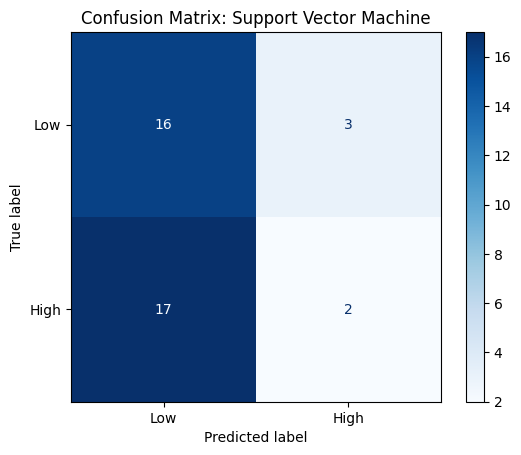


📌 Model: Naive Bayes
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        19
           1       1.00      0.68      0.81        19

    accuracy                           0.84        38
   macro avg       0.88      0.84      0.84        38
weighted avg       0.88      0.84      0.84        38



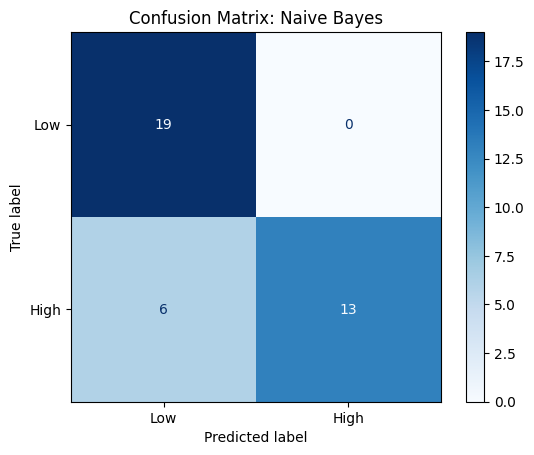


📌 Model: K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.53      0.53      0.53        19
           1       0.53      0.53      0.53        19

    accuracy                           0.53        38
   macro avg       0.53      0.53      0.53        38
weighted avg       0.53      0.53      0.53        38



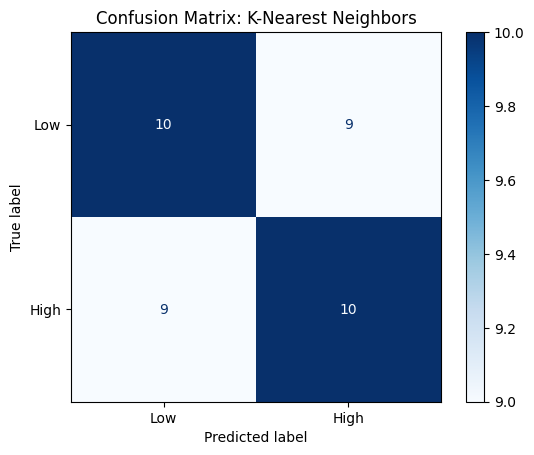

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(probability=True),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

for name, model in models.items():
    print(f"\n📌 Model: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()


## Thank you..pls upvote!!!